# Tutorial 3 — Generative Adversarial Networks (GAN)

This notebook uses the same **MNIST** dataset as Tutorial 2, so you can directly compare the
images a GAN produces against the AE and VAE outputs you already generated.

## Learning Outcomes
By the end of this lab you will be able to:
- Explain the generator/discriminator adversarial setup and the counterfeiter analogy
- Implement a GAN's Generator and Discriminator networks from scratch
- Derive and implement the minimax GAN objective (the value function V(D,G))
- Write the alternating training loop that updates D and G in turn
- Recognise and reproduce two classic GAN training failures: **mode collapse** and **vanishing gradients**
- Explain the connection between the GAN objective and Jensen-Shannon divergence
- Build a convolutional (DCGAN-style) Generator and Discriminator
- Evaluate generated images using a Fréchet-distance-style metric




## Running on a free GPU (Kaggle or Colab)

This tutorial **trains a GAN inside the notebook** (about 30 epochs on MNIST), so a GPU makes a real
difference: what takes several minutes per run on a laptop CPU finishes in well under a minute on a free
**T4** GPU. You can still run everything on CPU, it is just slower. Pick one of the two options below,
turn the GPU on, then run the notebook top to bottom.

### Option A - Kaggle (free T4, no setup)
1. Sign in at [kaggle.com](https://www.kaggle.com) (a free account; you verify your phone once to unlock GPUs).
2. **Upload this notebook:** *Create -> New Notebook -> File -> Import Notebook*, and choose this `.ipynb`.
3. Open the right-hand panel (the **`<`** arrow), find **Accelerator**, and set it to **GPU T4 x2**.
4. In the same panel, turn **Internet** **On** (the first cell downloads MNIST, which needs internet).
5. Run everything: *Run -> Run all*. Kaggle gives roughly 30 GPU hours per week, plenty for this lab.
6. To keep your results, click **Save Version** (top right); it stores the notebook with its outputs.

### Option B - Google Colab (free T4)
1. Open [colab.research.google.com](https://colab.research.google.com), then *File -> Upload notebook* and pick this `.ipynb`.
2. Turn the GPU on: *Runtime -> Change runtime type -> Hardware accelerator -> **T4 GPU** -> Save*.
3. Run everything: *Runtime -> Run all* (or press each cell with Shift+Enter).
4. Colab sessions are temporary, so download anything you want to keep: *File -> Download -> Download .ipynb*.

### Check the GPU is actually on
The setup cell below detects the device and prints it. You want it to say **`cuda`**:

```
Using device: cuda
```

If it prints `cpu`, the GPU is not enabled, go back and set the accelerator (steps above). You can also
run `!nvidia-smi` in a fresh cell to see the T4 and its memory. Everything in this notebook is small
enough that even the free tier is comfortable.


---
## Setup - Continuing from Tutorial 2

We start exactly the same way as Tutorial 2: import libraries, detect the device, and reload
MNIST. 


### Step 1 — Import libraries and detect the device

Same imports as Tutorial 2. We don't need anything new yet - GANs are built from the same
`nn.Linear`, `nn.ReLU` building blocks you already know.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ── Automatic device selection ──────────────────────────────────────
# Same code works everywhere: a laptop CPU, Apple MPS on a Mac, a free Kaggle/Colab
# T4, or a multi-GPU CUDA server. Leave the two settings on their defaults unless you
# want to force a particular device.
PREFER     = "auto"   # "auto" picks CUDA, else MPS, else CPU. Force with "cuda"/"mps"/"cpu".
CUDA_INDEX = None     # None = auto-pick the emptiest GPU; or an int to pin cuda:0, cuda:1, ...

def _list_cuda():
    # List every visible CUDA GPU with its free / total memory.
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)                     # bytes free / total on GPU i
        print(f"  cuda:{i}  {torch.cuda.get_device_name(i)}  "
              f"{free/1e9:.1f} GB free / {total/1e9:.1f} GB")

def _best_cuda():
    # Index of the CUDA GPU with the most free memory (handy on shared servers).
    frees = [torch.cuda.mem_get_info(i)[0] for i in range(torch.cuda.device_count())]
    return int(max(range(len(frees)), key=lambda i: frees[i]))

def pick_device(prefer="auto", cuda_index=None):
    has_cuda = torch.cuda.is_available()                             # Kaggle/Colab/servers
    has_mps  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()  # Mac
    if prefer == "cpu":                     return torch.device("cpu")
    if prefer == "mps" and has_mps:         return torch.device("mps")
    if prefer in ("auto", "cuda") and has_cuda:                      # pick a CUDA card
        idx = cuda_index if cuda_index is not None else _best_cuda()
        return torch.device(f"cuda:{idx}")
    if prefer == "auto" and has_mps:        return torch.device("mps")
    return torch.device("cpu")                                       # nothing else, use CPU

if torch.cuda.is_available():                                        # show the GPUs we can see
    print(f"CUDA available - {torch.cuda.device_count()} GPU(s):")
    _list_cuda()

device = pick_device(PREFER, CUDA_INDEX)                             # the device everything runs on
print("Using device:", device)


Using device: mps


### Step 2 — Download MNIST and create DataLoaders

Identical setup to Tutorial 2. Pixels are normalised to **(-1, 1)** because our Generator will
end with a `Tanh()` activation, exactly like the AE/VAE decoders did.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # pixel → (pixel - 0.5) / 0.5  → range (-1, 1)
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)   # shuffle=True for training
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)  # shuffle=False for evaluation

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Image shape      : {train_dataset[0][0].shape}")     # (channels, height, width)
print(f"Pixel range      : [{train_dataset[0][0].min():.2f}, {train_dataset[0][0].max():.2f}]")
print(f"Number of batches (train): {len(train_loader)}")


100.0%
100.0%
100.0%
100.0%

Training samples : 60,000
Test samples     : 10,000
Image shape      : torch.Size([1, 28, 28])
Pixel range      : [-1.00, 1.00]
Number of batches (train): 469


### Step 3 — Quick recap: AE vs VAE vs GAN

Before diving in, here is how the three generative approaches you will know by the end of this
course compare:

| | Autoencoder | VAE | GAN |
|---|---|---|---|
| Networks trained | 1 (Encoder+Decoder) | 1 (Encoder+Decoder) | **2** (Generator + Discriminator) |
| Learning signal | Reconstruction error | Reconstruction + KL divergence | **Adversarial competition** |
| Explicit density model? | No | Yes (approximate, via ELBO) | **No** |
| Can generate new samples? | Poorly (unstructured latent space) | Yes (regularised latent space) | **Yes, often sharper images** |
| Typical weakness | Can't sample | Slightly blurry outputs | **Unstable training, mode collapse** |

GANs trade the VAE's stability for sharper images — but as we'll see in Part 10, that trade-off
comes with real training headaches.


---
## Part 1: What is a GAN?

**Core idea is train two neural networks against each other.

- **Generator (G):** takes random noise `z` and tries to produce data that looks real.
- **Discriminator (D):** receives both real data and G's fake data, and tries to tell them apart.

Through this competition, the fake examples produced by G become progressively more realistic.

### The counterfeiter analogy

> A counterfeiter (Generator) tries to produce fake banknotes. The police (Discriminator) try to
> spot the fakes. As the police get better at spotting fakes, the counterfeiter is forced to
> improve. As the counterfeiter improves, the police must sharpen their detection skills further.
> Neither side can stand still.

This is genuinely a **zero-sum game**: whatever the Discriminator gains in detection accuracy,
the Generator loses in "fooling power" (and vice versa) — we will formalise this in Part 4.



### What each network learns

**Generator:**
- Takes random noise `z` as input (no real data ever passes through G directly).
- Has no explicit rules to learn — it only ever receives a learning signal *indirectly*, via the
  Discriminator's judgement of its outputs.
- Over time it learns to produce increasingly structured, realistic patterns.

**Discriminator:**
- Receives a mix of real images (from MNIST) and fake images (from G).
- Learns to distinguish the two using ordinary binary classification.
- The learning signal here is direct: the classification error on real vs fake.
- In effect, it becomes a learned **"critic" of realism**.


---
## Part 2: Building the Generator

The Generator's job is the mirror image of a decoder: it takes a low-dimensional noise vector
`z` and expands it into a full 28×28 image.

```
Noise z (latent_dim)  →  256  →  512  →  784  → Tanh   [Generator]
```

This is structurally **identical to the VAE decoder from Tutorial 2** — same shape, same final
`Tanh()`. The key difference is not the architecture, but *what trains it*: the VAE decoder was
trained to minimise reconstruction error against a specific input image; the GAN generator is
trained purely from the Discriminator's feedback, with no reconstruction target at all.

We build it in two steps so each piece is clear before assembling.


### Step 1 — Define the Generator network

Notice there is **no encoder** — unlike AE/VAE, a GAN's Generator never sees a real image. It
only ever sees random noise `z ~ N(0, I)`.

We use `LeakyReLU` instead of plain `ReLU` here. With ordinary `ReLU`, any neuron that goes
negative outputs exactly zero and its gradient is permanently zero — it can "die" and never
recover. `LeakyReLU` allows a small negative slope (default 0.01) so a unit can still receive a
gradient and recover. This matters more in GANs than in AE/VAE because adversarial training
already produces noisy, unstable gradients; we don't want dead neurons making it worse.


In [3]:
class Generator(nn.Module):
    """
    MLP Generator for MNIST.
    Noise z (latent_dim) → 256 → 512 → 784 → Tanh → image
    """
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()        # output in (-1, 1) to match normalised pixel range
        )

    def forward(self, z):
        img = self.net(z)
        return img.view(-1, 1, 28, 28)   # (batch, 784) → (batch, 1, 28, 28)


### Step 2 — Instantiate the Generator and inspect it

We use `latent_dim=100`, a common choice for GANs (much larger than the `latent_dim=2` or
`latent_dim=16` we used for AE/VAE — GANs typically need a higher-dimensional noise vector to
have enough "room" to encode the diversity of outputs).


In [4]:
latent_dim = 100   # size of the noise vector z

torch.manual_seed(42)
G = Generator(latent_dim=latent_dim).to(device)
print(G)
print(f"\nTotal parameters: {sum(p.numel() for p in G.parameters()):,}")

# Quick sanity check: feed random noise through an untrained Generator
z_sample = torch.randn(4, latent_dim).to(device)
fake_imgs = G(z_sample)
print(f"\nInput noise shape : {z_sample.shape}")
print(f"Output image shape: {fake_imgs.shape}")
print(f"Output pixel range: [{fake_imgs.min().item():.2f}, {fake_imgs.max().item():.2f}]  (untrained, so this is just structured noise)")


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total parameters: 559,632

Input noise shape : torch.Size([4, 100])
Output image shape: torch.Size([4, 1, 28, 28])
Output pixel range: [-0.43, 0.39]  (untrained, so this is just structured noise)


---
## Part 3: Building the Discriminator

The Discriminator is a **binary classifier**: given an image, output a single probability that
it is real.

```
Image (784)  →  512  →  256  →  1  → Sigmoid   [Discriminator]
```

This is structurally the mirror of the Generator — and notice it looks like the **encoder** half
of an Autoencoder, except the bottleneck has only **1 output unit** (real-vs-fake), not a latent
vector.


### Step 1 — Define the Discriminator network

`Sigmoid()` squashes the final output into `(0, 1)`, which we interpret as `D(x) = P(real | x)`.

We use `Dropout` here, which we have not used in AE/VAE. Dropout randomly zeroes a fraction of
neurons during training. This makes the Discriminator slightly "noisier" and harder to overfit
to specific real images — an overly confident, overly strong Discriminator is one of the classic
causes of unstable GAN training (Part 10), so we deliberately handicap it a little.


In [5]:
class Discriminator(nn.Module):
    """
    MLP Discriminator for MNIST.
    Image (784) → 512 → 256 → 1 → Sigmoid → P(real)
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()      # output in (0, 1) — interpreted as P(real)
        )

    def forward(self, img):
        x = img.view(-1, 784)   # (batch, 1, 28, 28) → (batch, 784)
        return self.net(x)


### Step 2 — Instantiate the Discriminator and inspect it


In [6]:
torch.manual_seed(42)
D = Discriminator().to(device)
print(D)
print(f"\nTotal parameters: {sum(p.numel() for p in D.parameters()):,}")

# Quick sanity check: feed one real batch and one fake batch through an untrained Discriminator
real_imgs, _ = next(iter(train_loader))
real_imgs = real_imgs.to(device)
fake_imgs = G(torch.randn(real_imgs.size(0), latent_dim).to(device))

with torch.no_grad():
    d_real = D(real_imgs)
    d_fake = D(fake_imgs)

print(f"\nD(real) — mean P(real) on actual MNIST digits : {d_real.mean().item():.4f}")
print(f"D(fake) — mean P(real) on untrained G's output : {d_fake.mean().item():.4f}")
print("\n(Both close to 0.5 right now — D hasn't learned anything yet, it's just guessing.)")


Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 533,505

D(real) — mean P(real) on actual MNIST digits : 0.5295
D(fake) — mean P(real) on untrained G's output : 0.5042

(Both close to 0.5 right now — D hasn't learned anything yet, it's just guessing.)


---
## Part 4: The GAN Objective

GAN training is formalised as a single **minimax value function**:

$$\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}\big[\log D(x)\big] + \mathbb{E}_{z \sim p_z(z)}\big[\log(1 - D(G(z)))\big]$$

Reading this term by term:
- $D(x) = 1$ means the Discriminator is certain `x` is real. $D(x) = 0$ means certain it's fake.
- The **Discriminator** wants to **maximise** $V(D,G)$: push $D(x) \to 1$ on real data and
  $D(G(z)) \to 0$ on fake data (both terms get larger as D classifies correctly).
- The **Generator** wants to **minimise** $V(D,G)$: push $D(G(z)) \to 1$, i.e. fool D into
  thinking fakes are real (this makes $\log(1 - D(G(z)))$ very negative).
- The **loss function** actually minimised in code is $-V(D,G)$ — turning the maximisation
  for D and the minimisation for G into two ordinary loss-minimisation problems.

### Connecting this to binary cross-entropy

You already know `nn.BCELoss()`. In fact, $V(D,G)$ is exactly the negative of two binary
cross-entropy terms:
- Treat real images as label `1` and fake images as label `0`.
- $-\log D(x)$ for label 1 and $-\log(1-D(G(z)))$ for label 0 are precisely the BCE loss terms.

This means **we don't need any custom loss function** for the GAN — `nn.BCELoss()` implements
$V(D,G)$ directly, as long as we feed it the right labels. This is simpler than the VAE loss from
Tutorial 2, which needed a hand-written KL divergence term.


### Step 1 — See the loss in code terms (no training yet)

Before writing the training loop, let's verify on the untrained networks from Parts 2–3 that
`BCELoss` really does give us $-V(D,G)$ piece by piece.


In [7]:
criterion = nn.BCELoss()

# Labels: real = 1, fake = 0
real_labels = torch.ones(real_imgs.size(0), 1).to(device)
fake_labels = torch.zeros(fake_imgs.size(0), 1).to(device)

with torch.no_grad():
    d_real = D(real_imgs)
    d_fake = D(fake_imgs.detach())

    # Discriminator loss: wants D(real)→1 and D(fake)→0
    loss_d_real = criterion(d_real, real_labels)
    loss_d_fake = criterion(d_fake, fake_labels)
    loss_d = loss_d_real + loss_d_fake

    # Generator loss: wants D(fake)→1 (fool the discriminator)
    loss_g = criterion(d_fake, real_labels)   # note: real_labels here, not fake_labels!

print(f"Discriminator loss (real part): {loss_d_real.item():.4f}")
print(f"Discriminator loss (fake part): {loss_d_fake.item():.4f}")
print(f"Discriminator total loss      : {loss_d.item():.4f}")
print(f"Generator loss                : {loss_g.item():.4f}")
print("\nAll values near log(2) ≈ 0.693, because both networks are untrained and D is essentially guessing 0.5 everywhere.")


Discriminator loss (real part): 0.6265
Discriminator loss (fake part): 0.6998
Discriminator total loss      : 1.3263
Generator loss                : 0.6866

All values near log(2) ≈ 0.693, because both networks are untrained and D is essentially guessing 0.5 everywhere.


**Why `real_labels` for the Generator's loss?** The Generator is *not* trying to make D say "fake" — it is trying to make D say
"real" about its fakes. So when we compute the Generator's loss, we tell `BCELoss` that the
target label is `1` (real), even though the images are actually fake. The loss is then small only
when D was successfully fooled — that low loss becomes the Generator's training signal.


---
## Part 5: Game Theory and the Nash Equilibrium

GAN training is best understood through the lens of **game theory** — the study of how multiple
agents make decisions that affect each other.

- Familiar examples of such games: chess players, competing companies.
- Agents in a game often have **conflicting objectives** — one classic example is the
  *prisoner's dilemma*.
- A GAN is specifically a **2-player zero-sum game**: whatever the Discriminator gains in
  accuracy, the Generator loses in fooling power, and vice versa. The two values sum to a
  constant.

### What is a Nash Equilibrium?

A **Nash equilibrium** is a state where **neither player can improve by changing their own
strategy alone** — each player is already playing their best possible response to what the other
is doing.

For GANs, the theoretical Nash equilibrium has two parts:
- **Best Generator:** perfectly imitates the real data distribution, $p_g(x) = p_{\text{data}}(x)$.
- **Best Discriminator:** can do no better than randomly guess, $D(x) = 0.5$ for every input
  (real or fake) — because if $p_g = p_{\text{data}}$, there is genuinely no information left
  that distinguishes them.

This is the **theoretical goal** of GAN training. In practice, training rarely reaches this exact
equilibrium — but it's the target we're aiming for, and it explains *why* a well-trained
Discriminator's accuracy should drift toward 50% as training progresses (rather than toward 100%,
which would mean the Generator has failed).


### Step 1 — A toy 2-player game to build intuition

Before returning to GANs, here's an extremely small numerical example of "neither player can
improve alone" using a simplified payoff table — this is *not* GAN code, just game theory
intuition. Skip ahead to Step 2 if you're comfortable with the concept already.


In [8]:
# A tiny matching-pennies-style zero-sum game.
# Player A picks a strategy (row), Player B picks a strategy (column).
# Payoff shown is A's gain (B's loss is the negative of this, since it's zero-sum).
payoff_to_A = np.array([
    [ 1, -1],   # A plays "Heads"
    [-1,  1],   # A plays "Tails"
])

print("Payoff to Player A (zero-sum: B's payoff is the negative of this):")
print(payoff_to_A)
print()
print("There is no single (row, column) pair where BOTH players are simultaneously happy")
print("with their own choice and unwilling to switch — the only equilibrium is a MIXED")
print("strategy: each player picks Heads/Tails with 50% probability.")
print()
print("This is the direct analogue of the GAN equilibrium D(x) = 0.5: when neither player")
print("can gain an advantage by deviating, both settle into an unpredictable middle ground.")


Payoff to Player A (zero-sum: B's payoff is the negative of this):
[[ 1 -1]
 [-1  1]]

There is no single (row, column) pair where BOTH players are simultaneously happy
with their own choice and unwilling to switch — the only equilibrium is a MIXED
strategy: each player picks Heads/Tails with 50% probability.

This is the direct analogue of the GAN equilibrium D(x) = 0.5: when neither player
can gain an advantage by deviating, both settle into an unpredictable middle ground.


---
## Part 6: The GAN Training Loop

This is the trickiest part of building a GAN, because **two networks are trained in alternation,
each with its own optimiser**, in every single batch:

1. **Update D:** show it a batch of real images (label 1) and a batch of fake images from G
   (label 0). Compute BCE loss, backprop, step D's optimiser only.
2. **Update G:** generate a fresh batch of fake images, pass them through the (now slightly
   updated) D, and compute the Generator's loss using the "fool D" trick from Part 4. Backprop,
   step G's optimiser only.

Compare this to the single-network training loop from Tutorial 2 (Part 4) — same five-step
pattern (forward → loss → zero_grad → backward → step), just **run twice per batch**, once for
each network, with separate optimisers.

A subtle but critical detail: when training D on fake images, we must call `.detach()` on G's
output. This stops gradients from flowing back into G during D's update — at this point in the
loop we only want to adjust D's weights, not G's.


### Step 1 — Re-initialise fresh networks and optimisers

We start from scratch with new `G` and `D` instances (the ones from Parts 2–3 were only for
demonstrating shapes and losses, not for actual training).

Each network gets its **own** Adam optimiser — this is essential, since `optimizer_D.step()`
must never touch G's parameters and vice versa.


In [9]:
torch.manual_seed(42)
G = Generator(latent_dim=latent_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

print("Generator and Discriminator (re)initialised.")
print(f"Generator params    : {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")
print()
print("Note: lr=2e-4 and betas=(0.5, 0.999) are the well-known DCGAN paper defaults —")
print("the standard Adam beta1=0.9 tends to make GAN training more unstable.")


Generator and Discriminator (re)initialised.
Generator params    : 559,632
Discriminator params: 533,505

Note: lr=2e-4 and betas=(0.5, 0.999) are the well-known DCGAN paper defaults —
the standard Adam beta1=0.9 tends to make GAN training more unstable.


### Step 2 — Write the function for a single Discriminator update

We separate this into its own function because we'll reuse the exact same logic whether we're
training the MLP GAN here or the convolutional DCGAN in Part 12.


In [10]:
def train_discriminator_step(generator, discriminator, opt_d, real_imgs, latent_dim):
    """One Discriminator update on a batch of real images + an equal batch of fakes."""
    batch_size = real_imgs.size(0)
    real_labels = torch.ones(batch_size, 1, device=device)
    fake_labels = torch.zeros(batch_size, 1, device=device)

    opt_d.zero_grad()

    # ── Real images: D should output close to 1 ─────────────────────
    d_real = discriminator(real_imgs)
    loss_d_real = criterion(d_real, real_labels)

    # ── Fake images: D should output close to 0 ─────────────────────
    z = torch.randn(batch_size, latent_dim, device=device)
    fake_imgs = generator(z).detach()   # detach! we are NOT updating G here
    d_fake = discriminator(fake_imgs)
    loss_d_fake = criterion(d_fake, fake_labels)

    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    opt_d.step()

    # Return values useful for monitoring training health
    return loss_d.item(), d_real.mean().item(), d_fake.mean().item()


### Step 3 — Write the function for a single Generator update

The Generator update uses a **fresh** batch of noise (not the same `z` used in the Discriminator
step) and does **not** detach — gradients must flow all the way back through D into G, since G's
weights are what we're updating.


In [11]:
def train_generator_step(generator, discriminator, opt_g, batch_size, latent_dim):
    """One Generator update: try to fool the (just-updated) Discriminator."""
    real_labels = torch.ones(batch_size, 1, device=device)   # G wants D to say "real"

    opt_g.zero_grad()

    z = torch.randn(batch_size, latent_dim, device=device)
    fake_imgs = generator(z)                # NOT detached — gradients must reach G
    d_fake = discriminator(fake_imgs)        # pass through D, but only G's optimiser will step
    loss_g = criterion(d_fake, real_labels)

    loss_g.backward()
    opt_g.step()

    return loss_g.item()


### Step 4 — Assemble the full training loop

Now we combine Steps 2–3 into the per-epoch loop, tracking losses and the Discriminator's mean
output on real vs fake images (a key health metric — see the box below).

**How to read the health metrics during training:**
- `D(real)` should stay reasonably high (close to but not exactly 1).
- `D(fake)` should rise over time from near 0 toward 0.5 as G improves.
- If `D(fake)` stays near 0 throughout training, the Discriminator is overpowering the Generator
  (see Part 10 — vanishing gradients).
- If `D(real)` and `D(fake)` are both stuck very close to 0.5 from the very first epoch with no
  improvement in image quality, something else is wrong (e.g. learning rate too high).


In [12]:
def train_gan(generator, discriminator, opt_g, opt_d, train_loader,
              epochs=30, latent_dim=100):
    history = {'loss_g': [], 'loss_d': [], 'd_real': [], 'd_fake': []}

    for epoch in range(epochs):
        generator.train()      # ensure Dropout/BatchNorm are in training mode
        discriminator.train()  # (important: an earlier .eval() call elsewhere would otherwise persist)
        running_g, running_d, running_d_real, running_d_fake = 0.0, 0.0, 0.0, 0.0

        for real_imgs, _ in train_loader:    # _ = digit label — NOT needed (unsupervised)
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ── Step A: update Discriminator ─────────────────────────
            loss_d, d_real_mean, d_fake_mean = train_discriminator_step(
                generator, discriminator, opt_d, real_imgs, latent_dim)

            # ── Step B: update Generator ──────────────────────────────
            loss_g = train_generator_step(
                generator, discriminator, opt_g, batch_size, latent_dim)

            running_g      += loss_g
            running_d       += loss_d
            running_d_real  += d_real_mean
            running_d_fake  += d_fake_mean

        n_batches = len(train_loader)
        history['loss_g'].append(running_g / n_batches)
        history['loss_d'].append(running_d / n_batches)
        history['d_real'].append(running_d_real / n_batches)
        history['d_fake'].append(running_d_fake / n_batches)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Loss_G: {history['loss_g'][-1]:.4f} | "
                  f"Loss_D: {history['loss_d'][-1]:.4f} | "
                  f"D(real): {history['d_real'][-1]:.3f} | "
                  f"D(fake): {history['d_fake'][-1]:.3f}")

    return history


---
## Part 7: Training the GAN

Now we run the full training loop on MNIST. GANs typically need **more epochs** than AE/VAE to
produce convincing results, and training is noticeably slower per epoch (two forward+backward
passes per batch instead of one). 


### Step 1 — Run training


In [13]:
torch.manual_seed(42)
G = Generator(latent_dim=latent_dim).to(device)
D = Discriminator().to(device)
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

gan_history = train_gan(G, D, optimizer_G, optimizer_D, train_loader,
                         epochs=30, latent_dim=latent_dim)
print("\nGAN training complete.")


Epoch   1/30 | Loss_G: 1.3610 | Loss_D: 0.8775 | D(real): 0.780 | D(fake): 0.424
Epoch   5/30 | Loss_G: 2.7068 | Loss_D: 0.5615 | D(real): 0.823 | D(fake): 0.182
Epoch  10/30 | Loss_G: 2.1852 | Loss_D: 0.6530 | D(real): 0.793 | D(fake): 0.210
Epoch  15/30 | Loss_G: 1.5376 | Loss_D: 0.8826 | D(real): 0.711 | D(fake): 0.295
Epoch  20/30 | Loss_G: 1.3150 | Loss_D: 0.9927 | D(real): 0.668 | D(fake): 0.338
Epoch  25/30 | Loss_G: 1.2382 | Loss_D: 1.0409 | D(real): 0.648 | D(fake): 0.354
Epoch  30/30 | Loss_G: 1.1829 | Loss_D: 1.0834 | D(real): 0.633 | D(fake): 0.369

GAN training complete.


### Step 2 — Plot the loss curves

Unlike AE/VAE loss curves, which steadily decrease, **GAN losses do not necessarily converge to
zero — and that's expected.** At the Nash equilibrium (Part 5), $D(x) = 0.5$ everywhere, which
corresponds to a *specific non-zero* loss value, not zero. Watch for oscillation rather than a
clean downward trend.


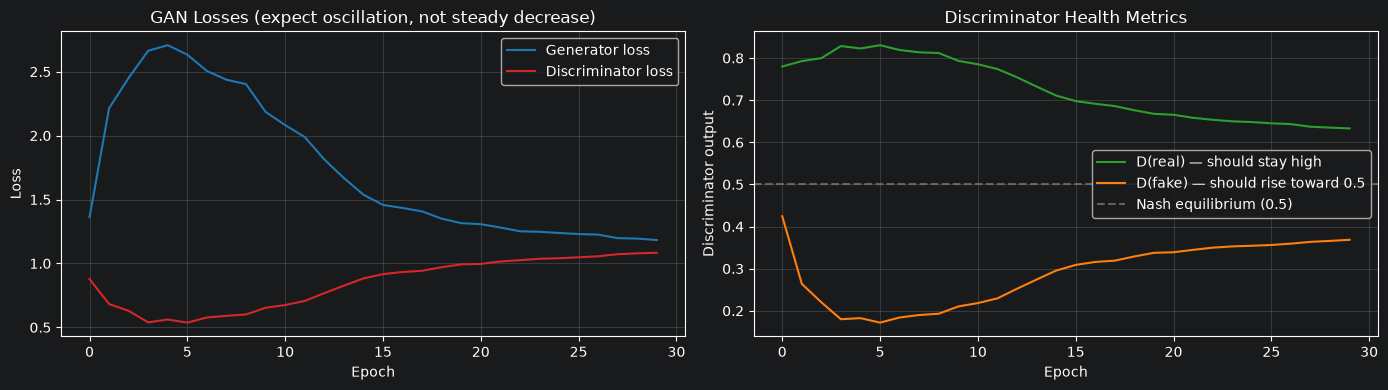

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gan_history['loss_g'], label='Generator loss', color='tab:blue')
axes[0].plot(gan_history['loss_d'], label='Discriminator loss', color='tab:red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GAN Losses (expect oscillation, not steady decrease)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(gan_history['d_real'], label='D(real) — should stay high', color='tab:green')
axes[1].plot(gan_history['d_fake'], label='D(fake) — should rise toward 0.5', color='tab:orange')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Nash equilibrium (0.5)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Discriminator output')
axes[1].set_title('Discriminator Health Metrics')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Part 8: Generating New Images

Now for the payoff: sample fresh noise vectors and decode them through the trained Generator.
Unlike the standard Autoencoder from Tutorial 2 (which produced garbage from random latent
vectors), a trained GAN Generator is **specifically designed** to take `N(0,I)` noise as input —
that's all it has ever seen during training.


### Step 1 — Sample random noise and generate digits


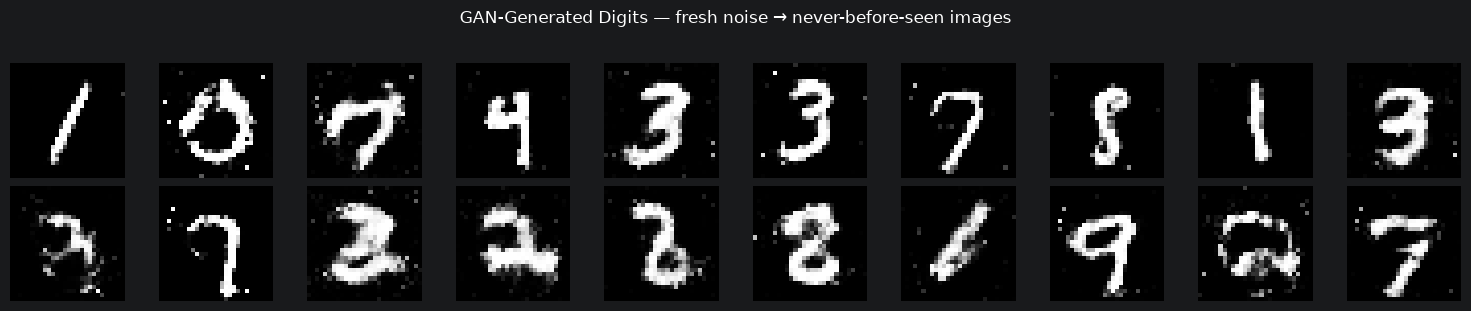

In [15]:
G.eval()
n_samples = 20

with torch.no_grad():
    z = torch.randn(n_samples, latent_dim, device=device)
    generated_imgs = G(z).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(n_samples):
    ax = axes[i // 10][i % 10]
    ax.imshow(generated_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('GAN-Generated Digits — fresh noise → never-before-seen images', y=1.02)
plt.tight_layout()
plt.show()


### Step 2 — Compare against a real MNIST batch

Side-by-side comparison: can you tell which row is real and which is generated, just by looking?
This is exactly the task the Discriminator was trained to do.


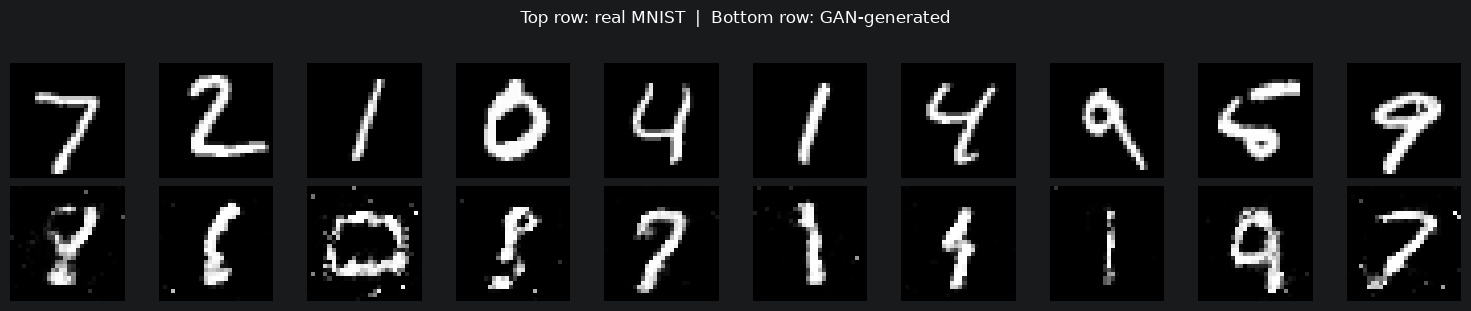

If you can reliably tell which row is fake, the Generator hasn't fully converged yet —
that's normal for an MLP GAN after only 30 epochs. The DCGAN in Part 12 usually does better.


In [16]:
real_sample, _ = next(iter(test_loader))
real_sample = real_sample[:10]

with torch.no_grad():
    z = torch.randn(10, latent_dim, device=device)
    fake_sample = G(z).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0][i].imshow(real_sample[i].squeeze(), cmap='gray')
    axes[0][i].axis('off')
    axes[1][i].imshow(fake_sample[i].squeeze(), cmap='gray')
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Real', fontsize=12, rotation=0, labelpad=40)
axes[1][0].set_ylabel('GAN', fontsize=12, rotation=0, labelpad=40)
plt.suptitle('Top row: real MNIST  |  Bottom row: GAN-generated', y=1.02)
plt.tight_layout()
plt.show()

print("If you can reliably tell which row is fake, the Generator hasn't fully converged yet —")
print("that's normal for an MLP GAN after only 30 epochs. The DCGAN in Part 12 usually does better.")


---
## Part 9: What Distance Is the GAN Actually Minimising?

In Tutorial 2, the VAE explicitly minimised a KL divergence term we could compute directly. GANs
have no such explicit term in their loss function — yet there is still a precise mathematical
answer to *what distance between distributions a GAN minimises*: the **Jensen-Shannon (JS)
divergence**.

### Definition

GAN training wants $p_g(x) \approx p_{\text{data}}(x)$ — the Generator's distribution should
match the real data distribution. To quantify how different two distributions are, define the
midpoint distribution $M(x) = \tfrac{1}{2}\big(p_{\text{data}}(x) + p_g(x)\big)$, then:

$$JS(p_{\text{data}} \,\|\, p_g) = \tfrac{1}{2}KL(p_{\text{data}}\|M) + \tfrac{1}{2}KL(p_g\|M)$$

Unlike plain KL divergence (which is asymmetric — $KL(P\|Q) \ne KL(Q\|P)$ in general), **JS
divergence is symmetric**: $JS(p_{\text{data}}\|p_g) = JS(p_g\|p_{\text{data}})$. It is also
always bounded: $0 \le JS(p_{\text{data}}\|p_g) \le \log 2$, even when the two distributions
share very little overlap (a case where plain KL divergence can blow up to infinity).

### How does this connect to the GAN we actually trained?

We never compute $p_{\text{data}}(x)$ or $p_g(x)$ directly — both are unknown, intractable
high-dimensional distributions over images. Instead, **the Discriminator itself acts as a proxy
for JS divergence**:

- The Discriminator estimates $D(x) = P(\text{real} \mid x)$.
- For a *fixed* Generator, the theoretically optimal Discriminator is
  $D^*(x) = \dfrac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$.
- Plugging this optimal $D^*$ back into the value function gives:
  $$V(D^*, G) = -\log 4 + 2\,JS(p_{\text{data}}\|p_g)$$

So minimising the GAN's value function with respect to G is — **provably, when D is trained to
its optimum at each step** — equivalent to minimising the JS divergence between the real and
generated distributions. This is the theoretical justification for why GAN training should push
$p_g \to p_{\text{data}}$.


### Step 1 — A small numerical demonstration of JS divergence

We can't compute JS divergence on real MNIST images directly (no closed-form density), but we
can illustrate the formula on simple categorical distributions, which makes the symmetry and
boundedness properties concrete.


In [17]:
def kl_divergence(p, q):
    """KL(p || q) for discrete distributions (numpy arrays, same support)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    mask = p > 0     # avoid log(0); terms where p=0 contribute 0 to KL by convention
    return np.sum(p[mask] * np.log(p[mask] / q[mask]))

def js_divergence(p, q):
    """JS(p || q) for discrete distributions."""
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

# Two toy "distributions" over 4 outcomes
p_data = np.array([0.5, 0.3, 0.1, 0.1])   # the "real" distribution
p_g_close  = np.array([0.45, 0.35, 0.1, 0.1])   # generator distribution: similar
p_g_far    = np.array([0.1, 0.1, 0.3, 0.5])     # generator distribution: very different

print(f"JS(p_data || p_g_close) = {js_divergence(p_data, p_g_close):.4f}   (similar distributions → small JS)")
print(f"JS(p_data || p_g_far)   = {js_divergence(p_data, p_g_far):.4f}   (different distributions → larger JS)")
print(f"log(2) (the theoretical maximum)  = {np.log(2):.4f}")
print()
print(f"Checking symmetry: JS(p_g_far || p_data) = {js_divergence(p_g_far, p_data):.4f}  (should match the line above)")


JS(p_data || p_g_close) = 0.0016   (similar distributions → small JS)
JS(p_data || p_g_far)   = 0.1979   (different distributions → larger JS)
log(2) (the theoretical maximum)  = 0.6931

Checking symmetry: JS(p_g_far || p_data) = 0.1979  (should match the line above)


---
## Part 10: GAN Challenges

GANs are notoriously harder to train than AE/VAE. Three classic problems:

1. **Difficult adversarial training** — the optimisation target for each network keeps changing
   as the other network updates. Unlike a normal loss landscape (which is fixed), G is chasing a
   moving target (D), and vice versa.
2. **Vanishing gradients** — if D becomes "too good too early," it classifies all of G's fakes
   correctly with high confidence. The loss $\log(1-D(G(z)))$ then saturates and its gradient
   with respect to G's parameters shrinks toward zero — G receives almost no learning signal and
   stops improving.
3. **Mode collapse** — G discovers a small set of outputs that reliably fool D, and stops
   exploring further. Instead of representing all 10 digits, the Generator might produce only
   2–3 digit shapes repeatedly, ignoring the rest of the data distribution's diversity.

We'll reproduce **mode collapse** concretely on an easy 2D toy dataset, where it's much easier to
see visually than buried inside 784-dimensional MNIST images.


### Step 1 — Build a toy 2D dataset with multiple separated clusters



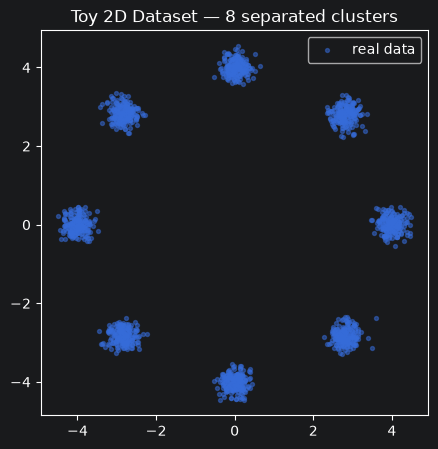

In [18]:
def make_ring_clusters(n_clusters=8, points_per_cluster=200, radius=4.0, std=0.2, seed=0):
    rng = np.random.RandomState(seed)
    centers = []
    for i in range(n_clusters):
        angle = 2 * np.pi * i / n_clusters
        centers.append([radius * np.cos(angle), radius * np.sin(angle)])
    centers = np.array(centers)

    points = []
    for c in centers:
        pts = rng.normal(loc=c, scale=std, size=(points_per_cluster, 2))
        points.append(pts)
    return np.concatenate(points, axis=0).astype(np.float32), centers

toy_data, toy_centers = make_ring_clusters()
toy_tensor = torch.tensor(toy_data)
toy_loader = DataLoader(toy_tensor, batch_size=64, shuffle=True)

plt.figure(figsize=(5, 5))
plt.scatter(toy_data[:, 0], toy_data[:, 1], s=8, alpha=0.5, label='real data')
plt.title('Toy 2D Dataset — 8 separated clusters')
plt.legend()
plt.axis('equal')
plt.show()


### Step 2 — Build a small GAN for 2D data

Same architecture pattern as Parts 2–3, just with `input_dim=2` instead of 784. We intentionally
use a **strong Discriminator and weak Generator** (D has more capacity and no dropout) — this is
one of the classic recipes for triggering both vanishing gradients and mode collapse, so we can
observe the failure on purpose.


In [19]:
class ToyGenerator(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)   # no Tanh needed — toy data isn't pixel-bounded
        )

    def forward(self, z):
        return self.net(z)


class ToyDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),     # deliberately large — an overpowered Discriminator
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


### Step 3 — Train the toy GAN and record snapshots of G's output over time

We save the Generator's output every few epochs so we can visualise mode collapse as it happens,
rather than only seeing the final (already-collapsed) result.


In [20]:
def train_toy_gan(epochs=300, latent_dim=2, snapshot_every=30):
    torch.manual_seed(7)
    g = ToyGenerator(latent_dim=latent_dim)
    d = ToyDiscriminator()
    opt_g = optim.Adam(g.parameters(), lr=1e-3)
    opt_d = optim.Adam(d.parameters(), lr=1e-3)
    bce = nn.BCELoss()

    snapshots = []

    for epoch in range(epochs):
        for real_batch in toy_loader:
            batch_size = real_batch.size(0)
            real_labels = torch.ones(batch_size, 1)
            fake_labels = torch.zeros(batch_size, 1)

            # --- Discriminator update ---
            opt_d.zero_grad()
            d_real = d(real_batch)
            loss_d_real = bce(d_real, real_labels)

            z = torch.randn(batch_size, latent_dim)
            fake_batch = g(z).detach()
            d_fake = d(fake_batch)
            loss_d_fake = bce(d_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_d.step()

            # --- Generator update ---
            opt_g.zero_grad()
            z = torch.randn(batch_size, latent_dim)
            fake_batch = g(z)
            d_fake = d(fake_batch)
            loss_g = bce(d_fake, real_labels)
            loss_g.backward()
            opt_g.step()

        if epoch % snapshot_every == 0 or epoch == epochs - 1:
            with torch.no_grad():
                z = torch.randn(500, latent_dim)
                snap = g(z).numpy()
            snapshots.append((epoch, snap))

    return g, d, snapshots

toy_g, toy_d, snapshots = train_toy_gan()
print(f"Captured {len(snapshots)} snapshots at epochs: {[s[0] for s in snapshots]}")


Captured 11 snapshots at epochs: [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 299]


### Step 4 — Visualise mode collapse happening over training


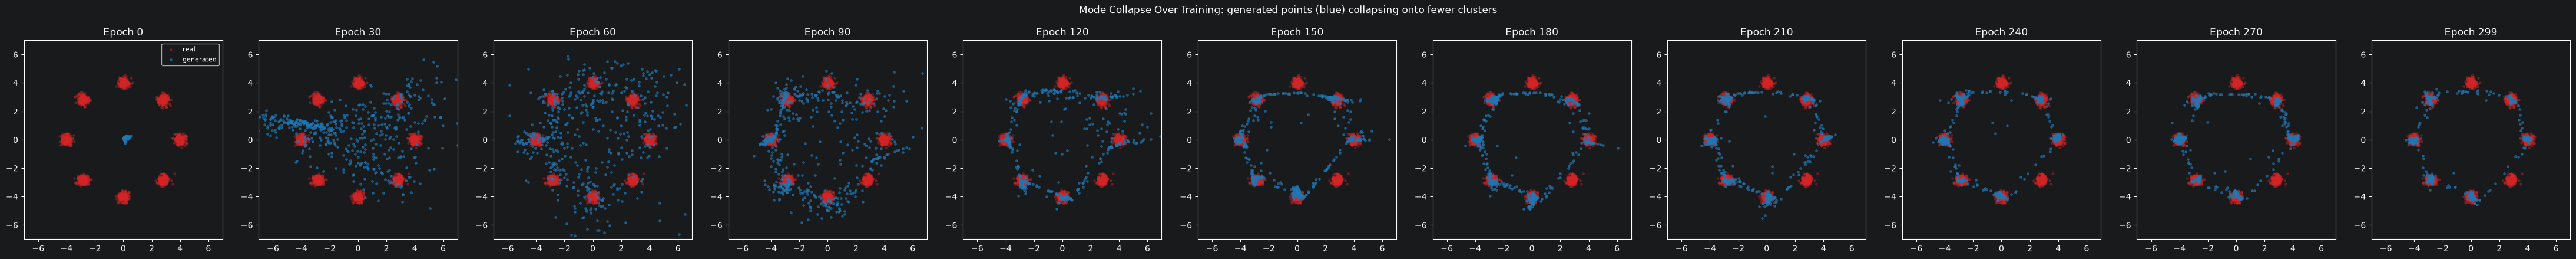

If mode collapse occurred, you'll see the blue points concentrate on only 1-3 of the
8 red clusters by the final epoch, instead of spreading evenly across all 8 — exactly


In [21]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))

for ax, (epoch, snap) in zip(axes, snapshots):
    ax.scatter(toy_data[:, 0], toy_data[:, 1], s=6, alpha=0.3, color='tab:red', label='real')
    ax.scatter(snap[:, 0], snap[:, 1], s=6, alpha=0.6, color='tab:blue', label='generated')
    ax.set_title(f'Epoch {epoch}')
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect('equal')

axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Mode Collapse Over Training: generated points (blue) collapsing onto fewer clusters', y=1.03)
plt.tight_layout()
plt.show()

print("If mode collapse occurred, you'll see the blue points concentrate on only 1-3 of the")
print("8 red clusters by the final epoch, instead of spreading evenly across all 8 — exactly")


### Step 5 — Diagnose with the Discriminator health metric

Recall from Part 7: `D(fake)` should rise toward 0.5 as training progresses. If mode collapse or
vanishing gradients occurred, you'll typically see `D(fake)` stuck very close to 0 even late in
training — a strong, clear diagnostic signal.


In [22]:
with torch.no_grad():
    z = torch.randn(500, 2)
    fake_final = toy_g(z)
    d_real_final = toy_d(toy_tensor).mean().item()
    d_fake_final = toy_d(fake_final).mean().item()

print(f"Final D(real): {d_real_final:.4f}  (should be reasonably high)")
print(f"Final D(fake): {d_fake_final:.4f}  (if stuck near 0, this confirms vanishing gradients / mode collapse)")
print()
print("Common fixes (not implemented here, but worth knowing):")
print("  - Lower the Discriminator's learning rate relative to the Generator's")
print("  - Add label smoothing (use labels like 0.9 instead of 1.0 for 'real')")
print("  - Use minibatch discrimination or unrolled GANs to directly penalise low diversity")
print("  - Switch to a Wasserstein GAN (WGAN) loss, which avoids the vanishing-gradient regime entirely")


Final D(real): 0.6250  (should be reasonably high)
Final D(fake): 0.4474  (if stuck near 0, this confirms vanishing gradients / mode collapse)

Common fixes (not implemented here, but worth knowing):
  - Lower the Discriminator's learning rate relative to the Generator's
  - Add label smoothing (use labels like 0.9 instead of 1.0 for 'real')
  - Use minibatch discrimination or unrolled GANs to directly penalise low diversity
  - Switch to a Wasserstein GAN (WGAN) loss, which avoids the vanishing-gradient regime entirely


---
## Part 11: Exercises

###  Exercise 1 — Experimenting with the MNIST GAN

1. Go back to Part 7 and retrain the MNIST GAN for only **5 epochs** instead of 30. Generate a
   batch of images (Part 8, Step 1). How does the quality compare? Is mode collapse visible
   (e.g. several generated digits looking nearly identical)?
2. Try setting `latent_dim = 10` instead of 100 when creating `Generator` and `Discriminator`,
   then retrain for 15 epochs. Does a smaller noise vector limit the diversity of generated
   digits? Why might this happen, given what `z` represents?
3. In `train_discriminator_step`, try removing the `.detach()` call on `fake_imgs`. Run a single
   training epoch. Does it still work? (Hint: think about which optimiser's `.step()` actually
   gets called, and whether removing detach changes *what gradients are computed* vs *whose
   weights actually get updated*.)


Epoch   1/5 | Loss_G: 1.3610 | Loss_D: 0.8775 | D(real): 0.780 | D(fake): 0.424
Epoch   5/5 | Loss_G: 2.7068 | Loss_D: 0.5615 | D(real): 0.823 | D(fake): 0.182


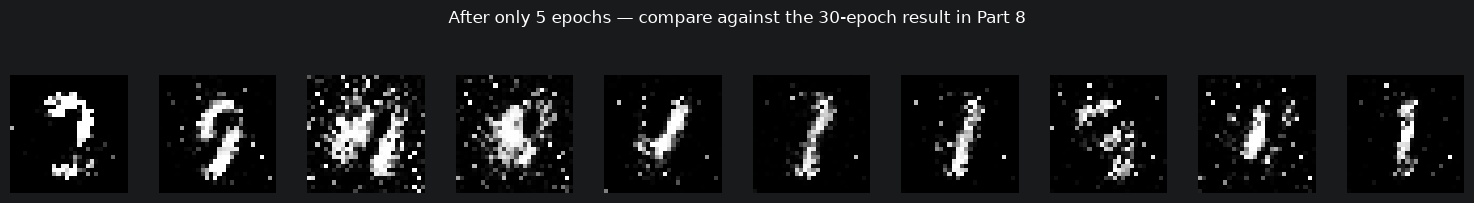

TODO: Try latent_dim=10 yourself (re-run Part 6 Step 1 with latent_dim=10, then Part 7).
TODO: Try removing .detach() in train_discriminator_step and observe what happens.


In [23]:
# ── Exercise 1 ───────────────────────────────────────────────────────

# 1. Retrain for only 5 epochs
torch.manual_seed(42)
G_short = Generator(latent_dim=latent_dim).to(device)
D_short = Discriminator().to(device)
opt_g_short = optim.Adam(G_short.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d_short = optim.Adam(D_short.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Temporarily point the global G, D, optimizers used inside the step functions
G, D, optimizer_G, optimizer_D = G_short, D_short, opt_g_short, opt_d_short
history_short = train_gan(G, D, optimizer_G, optimizer_D, train_loader, epochs=5, latent_dim=latent_dim)

G.eval()
with torch.no_grad():
    z = torch.randn(10, latent_dim, device=device)
    imgs_5ep = G(z).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 1.8))
for i in range(10):
    axes[i].imshow(imgs_5ep[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('After only 5 epochs — compare against the 30-epoch result in Part 8', y=1.1)
plt.tight_layout()
plt.show()

print("TODO: Try latent_dim=10 yourself (re-run Part 6 Step 1 with latent_dim=10, then Part 7).")
print("TODO: Try removing .detach() in train_discriminator_step and observe what happens.")


---
## Part 12: CNNs in GANs — DCGAN

Everything so far used plain `Linear` layers (an MLP GAN), matching Tutorial 2's style. This is a
good way to learn the *mechanics* of adversarial training, but in practice, real image GANs
almost always use **convolutional layers** instead. 

### Why convolutions help

- **Convolutional layers preserve spatial information** — an MLP flattens the image into a flat
  784-vector immediately, throwing away the fact that nearby pixels are related.
- **Parameter sharing across locations** — the same small filter slides across the whole image,
  rather than learning a separate weight for every pixel position.
- **Hierarchical features** — early layers learn edges/strokes, later layers combine them into
  digit-like shapes.

This convolutional approach to GANs is called **DCGAN** (Deep Convolutional GAN), and it's
standard practice to use CNNs in *both* the generator and discriminator.



### Step 1 — Define the DCGAN Generator

`nn.ConvTranspose2d` is the "reverse" of a normal convolution: instead of shrinking the spatial
size, it **grows** it. 

`nn.BatchNorm2d` is new — it normalises activations within each batch, which significantly
stabilises GAN training (this is a standard DCGAN-paper recommendation, not used in our MLP
version).


In [24]:
class DCGenerator(nn.Module):
    """
    Convolutional Generator for MNIST (28x28).
    z (latent_dim) → project+reshape to 7x7x128 → upsample to 14x14x64 → upsample to 28x28x1
    """
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim

        # Project noise vector into a small spatial tensor (the "Project and reshape" step)
        self.project = nn.Linear(latent_dim, 128 * 7 * 7)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 7x7 → 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 14x14 → 28x28
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()    # output in (-1, 1), same convention as the MLP version
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(-1, 128, 7, 7)     # reshape flat vector into a spatial tensor
        return self.conv_blocks(x)


### Step 2 — Define the DCGAN Discriminator

The Discriminator mirrors the Generator: ordinary `nn.Conv2d` layers **shrink** the spatial size
(`stride=2`) while increasing the channel depth, until we flatten down to a single real/fake
score — this is the standard CNN classifier pattern, just without a final softmax over classes.


In [25]:
class DCDiscriminator(nn.Module):
    """
    Convolutional Discriminator for MNIST (28x28).
    28x28x1 → 14x14x64 → 7x7x128 → flatten → 1 → Sigmoid
    """
    def __init__(self):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # 28x28 → 14x14
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 14x14 → 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        x = self.conv_blocks(img)
        x = x.view(x.size(0), -1)   # flatten (batch, 128, 7, 7) → (batch, 128*7*7)
        return self.classifier(x)


### Step 3 — Train the DCGAN

We reuse the exact same `train_discriminator_step` / `train_generator_step` / `train_gan`
functions from Part 6 — they only reference the global `G`, `D`, `optimizer_G`, `optimizer_D`,
`criterion`, and `latent_dim` variables, so swapping in convolutional networks requires no
changes to the training logic itself. This is a good illustration of why we wrote the training
loop as reusable functions rather than one big inline block.


In [26]:
torch.manual_seed(42)
G = DCGenerator(latent_dim=latent_dim).to(device)
D = DCDiscriminator().to(device)
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

print(f"DCGAN Generator params    : {sum(p.numel() for p in G.parameters()):,}")
print(f"DCGAN Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

dcgan_history = train_gan(G, D, optimizer_G, optimizer_D, train_loader,
                           epochs=20, latent_dim=latent_dim)
print("\nDCGAN training complete.")


DCGAN Generator params    : 766,017
DCGAN Discriminator params: 138,561
Epoch   1/20 | Loss_G: 1.7054 | Loss_D: 0.9101 | D(real): 0.682 | D(fake): 0.334
Epoch   5/20 | Loss_G: 1.1513 | Loss_D: 1.0878 | D(real): 0.624 | D(fake): 0.378
Epoch  10/20 | Loss_G: 0.9312 | Loss_D: 1.2253 | D(real): 0.569 | D(fake): 0.431
Epoch  15/20 | Loss_G: 0.9517 | Loss_D: 1.2211 | D(real): 0.571 | D(fake): 0.429
Epoch  20/20 | Loss_G: 0.9615 | Loss_D: 1.2225 | D(real): 0.573 | D(fake): 0.428

DCGAN training complete.


### Step 4 — Compare DCGAN output against the MLP GAN

Generate fresh samples and compare visually against Part 8's MLP GAN output.


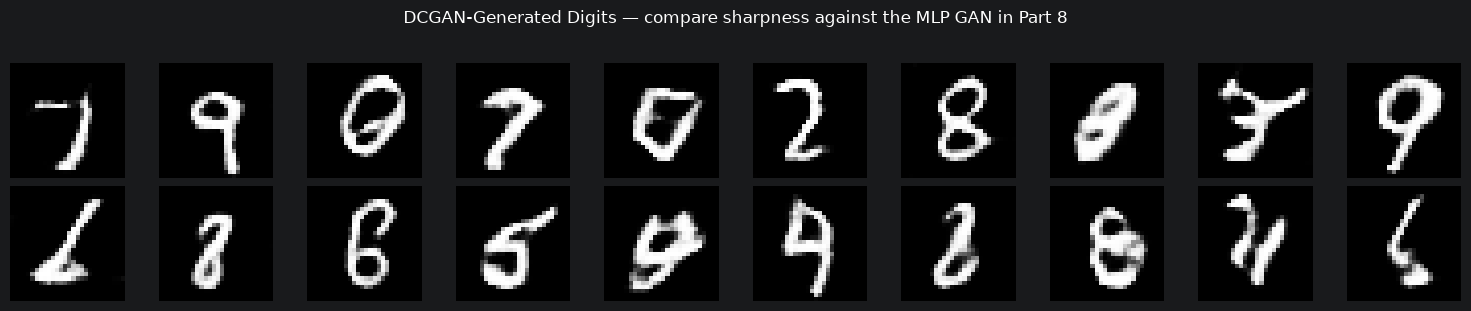

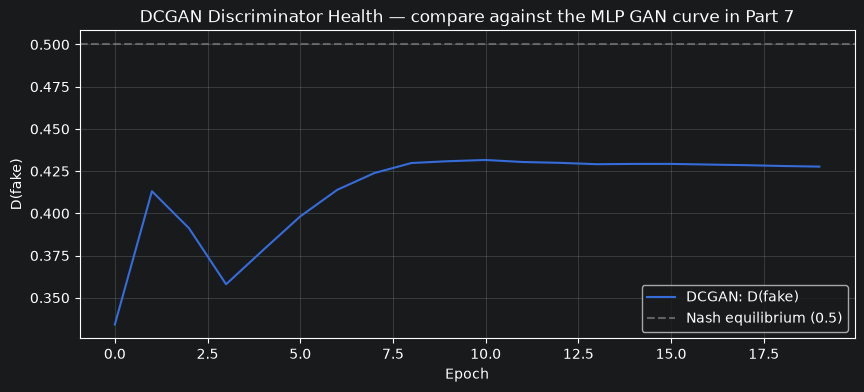

In [27]:
G.eval()
with torch.no_grad():
    z = torch.randn(20, latent_dim, device=device)
    dcgan_imgs = G(z).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10][i % 10]
    ax.imshow(dcgan_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('DCGAN-Generated Digits — compare sharpness against the MLP GAN in Part 8', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(dcgan_history['d_fake'], label='DCGAN: D(fake)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Nash equilibrium (0.5)')
plt.xlabel('Epoch')
plt.ylabel('D(fake)')
plt.title('DCGAN Discriminator Health — compare against the MLP GAN curve in Part 7')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Part 13: Evaluating Generated Image Quality

So far we've judged GAN output **by eye** — looking at grids of digits and asking "does this look
real?" That doesn't scale, and it isn't reproducible. We need a quantitative metric.

A good generative-image metric should reward outputs that are:
- **Realistic** — individual images look like real data.
- **Diverse** — outputs cover the full variety of the real data (directly penalises mode collapse!).
- **Representative** — the *overall distribution* of generated images matches the real data's
  distribution.

### Fréchet Inception Distance (FID)

The most popular metric for this is the **Fréchet Inception Distance (FID)**:
1. Pass a large batch of real images and a large batch of generated images through a pretrained
   image classifier (originally Inception-v3, trained on ImageNet), and take the activations
   from one of its late layers as a feature vector for each image.
2. Model both sets of features as multivariate Gaussians (estimate mean and covariance for each).
3. Compute the **Fréchet distance** between the two Gaussians:
   $$\text{FID} = \|\mu_{\text{real}} - \mu_{\text{gen}}\|^2 + \text{Tr}\big(\Sigma_{\text{real}} + \Sigma_{\text{gen}} - 2(\Sigma_{\text{real}}\Sigma_{\text{gen}})^{1/2}\big)$$
4. **Lower FID is better** — it means the generated images' feature distribution is closer to
   the real images' feature distribution.

The real Inception-v3 network expects 3-channel, 299×299 ImageNet-style images, which is overkill
for MNIST and not practical to download in a tutorial session. Instead, we implement the **same
Fréchet-distance formula**, but using a much simpler feature extractor: the 16-dimensional latent
vectors from the **Tutorial 2 Autoencoder encoder** (or, if you don't have it trained, simple raw
pixel statistics). This preserves the actual evaluation logic while staying lightweight.


### Step 1 — Implement the Fréchet distance formula


In [28]:
from scipy import linalg

def frechet_distance(mu1, sigma1, mu2, sigma2):
    """
    Compute the Frechet distance between two multivariate Gaussians,
    parameterised by (mean, covariance) pairs. Same formula used by FID,
    just applied to whatever feature vectors we hand it.
    """
    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

def get_feature_stats(images_flat):
    """images_flat: (N, D) numpy array of feature vectors -> (mean, covariance)."""
    mu = images_flat.mean(axis=0)
    sigma = np.cov(images_flat, rowvar=False)
    return mu, sigma


### Step 2 — Extract simple pixel-statistic features and compute our FID-style score

We use a lightweight 7x7-downsampled pixel representation as our "feature extractor" — simple,
fast, requires no extra model, and still captures enough structure to meaningfully separate good
generators from a mode-collapsed one.


In [29]:
def extract_simple_features(images):
    """images: (N, 1, 28, 28) tensor in (-1,1) -> (N, 49) numpy array, 7x7 average-pooled."""
    pooled = nn.functional.avg_pool2d(images, kernel_size=4)   # 28x28 -> 7x7... close enough
    return pooled.view(images.size(0), -1).cpu().numpy()

# Real features: a few batches of real test images
real_batches = []
for imgs, _ in test_loader:
    real_batches.append(imgs)
    if len(real_batches) >= 8:   # ~1000 images is plenty for this simplified metric
        break
real_imgs_eval = torch.cat(real_batches, dim=0)
real_features = extract_simple_features(real_imgs_eval)


**Note:** to keep this section runnable on its own (regardless of whether Part 12's DCGAN has overwritten the global `G`/`D`), we retrain a fresh, quick MLP Generator and Discriminator below specifically for this evaluation. If you already have a longer-trained MLP `G` in memory from Part 7, feel free to skip the retrain cell and reuse it instead.


In [30]:
# Quick retrain so this section works standalone even if Part 12 overwrote the global G/D
torch.manual_seed(42)
G_eval = Generator(latent_dim=latent_dim).to(device)
D_eval = Discriminator().to(device)
opt_g_eval = optim.Adam(G_eval.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d_eval = optim.Adam(D_eval.parameters(), lr=2e-4, betas=(0.5, 0.999))

G, D, optimizer_G, optimizer_D = G_eval, D_eval, opt_g_eval, opt_d_eval
_ = train_gan(G, D, optimizer_G, optimizer_D, train_loader, epochs=15, latent_dim=latent_dim)

G.eval()
with torch.no_grad():
    z = torch.randn(real_imgs_eval.size(0), latent_dim, device=device)
    gen_imgs_eval = G(z).cpu()

gen_features = extract_simple_features(gen_imgs_eval)

mu_real, sigma_real = get_feature_stats(real_features)
mu_gen,  sigma_gen  = get_feature_stats(gen_features)

fid_score = frechet_distance(mu_real, sigma_real, mu_gen, sigma_gen)


Epoch   1/15 | Loss_G: 1.3610 | Loss_D: 0.8775 | D(real): 0.780 | D(fake): 0.424
Epoch   5/15 | Loss_G: 2.7068 | Loss_D: 0.5615 | D(real): 0.823 | D(fake): 0.182
Epoch  10/15 | Loss_G: 2.1852 | Loss_D: 0.6530 | D(real): 0.793 | D(fake): 0.210
Epoch  15/15 | Loss_G: 1.5376 | Loss_D: 0.8826 | D(real): 0.711 | D(fake): 0.295


/var/folders/nc/y9p62kcn66n6x16cnfbbmh640000gn/T/ipykernel_59254/3637457341.py:10: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma1 @ sigma2)


### Step 3 — Compare against a deliberately bad generator (untrained)

To confirm the metric behaves sensibly, compute the same score for a completely untrained
Generator — it should score noticeably worse (higher) than the trained one above.


In [31]:
torch.manual_seed(99)
G_untrained = Generator(latent_dim=latent_dim).to(device)
G_untrained.eval()

with torch.no_grad():
    z = torch.randn(real_imgs_eval.size(0), latent_dim, device=device)
    gen_imgs_untrained = G_untrained(z).cpu()

gen_features_untrained = extract_simple_features(gen_imgs_untrained)
mu_bad, sigma_bad = get_feature_stats(gen_features_untrained)

fid_untrained = frechet_distance(mu_real, sigma_real, mu_bad, sigma_bad)

print(f"Trained GAN score   : {fid_score:.4f}")
print(f"Untrained GAN score : {fid_untrained:.4f}")


Trained GAN score   : 0.9636
Untrained GAN score : 37.1252


/var/folders/nc/y9p62kcn66n6x16cnfbbmh640000gn/T/ipykernel_59254/3637457341.py:10: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma1 @ sigma2)


---
## Part 14: Saving and Loading the GAN

Same pattern as Tutorial 2: save each network's `state_dict`, recreate the architecture, load it
back. With a GAN, we save **both** networks — in practice you usually only need the Generator
for downstream use (image generation), but saving the Discriminator too lets you resume
adversarial training later without starting from an untrained, randomly-guessing Discriminator.


### Step 1 — Save the trained Generator and Discriminator weights to disk


In [32]:
# Record which architecture G currently is, so Step 2 can reload correctly
# regardless of whether you last ran the MLP GAN (Part 7/13) or the DCGAN (Part 12).
gan_architecture = type(G).__name__   # 'Generator' or 'DCGenerator'

torch.save(G.state_dict(), 'gan_generator_mnist.pth')
torch.save(D.state_dict(), 'gan_discriminator_mnist.pth')
print(f"Saved Generator architecture : {gan_architecture}")
print("Saved: gan_generator_mnist.pth")
print("Saved: gan_discriminator_mnist.pth")

# Show what keys are saved (layer names) for the Generator
state = torch.load('gan_generator_mnist.pth', map_location='cpu')
print(f"\nNumber of parameter tensors saved (Generator): {len(state)}")
for key in list(state.keys())[:5]:
    print(f"  {key}: shape {state[key].shape}")
print("  ...")


Saved Generator architecture : Generator
Saved: gan_generator_mnist.pth
Saved: gan_discriminator_mnist.pth

Number of parameter tensors saved (Generator): 6
  net.0.weight: shape torch.Size([256, 100])
  net.0.bias: shape torch.Size([256])
  net.2.weight: shape torch.Size([512, 256])
  net.2.bias: shape torch.Size([512])
  net.4.weight: shape torch.Size([784, 512])
  ...


### Step 2 — Load the Generator back and verify it produces identical outputs

**Critical:** you must create a model with the **same architecture** before loading. Step 1 recorded which architecture was last trained in the `gan_architecture` variable, so this cell automatically reconstructs the right class — whether that's the MLP `Generator` (Parts 7/13) or the convolutional `DCGenerator` (Part 12). `load_state_dict` would raise a clear error if the architectures didn't match, which is a useful sanity check in itself.


In [33]:
# Recreate the architecture — must match what was actually saved above.
# We use the `gan_architecture` string recorded in Step 1 so this cell works correctly
# whether you last trained the MLP Generator or the convolutional DCGenerator.
if gan_architecture == 'DCGenerator':
    loaded_G = DCGenerator(latent_dim=latent_dim)
else:
    loaded_G = Generator(latent_dim=latent_dim)

loaded_G.load_state_dict(torch.load('gan_generator_mnist.pth', map_location='cpu'))
loaded_G.eval()
print(f"Loaded: {gan_architecture}(latent_dim={latent_dim}) from gan_generator_mnist.pth")

# Verify outputs are identical
G.eval()
with torch.no_grad():
    torch.manual_seed(123)
    z_test = torch.randn(1, latent_dim)
    out1 = G(z_test.to(device)).cpu()       # original model
    out2 = loaded_G(z_test)                  # loaded model (on CPU)

print("\nVerification:")
print(f"  Generated images match: {torch.allclose(out1, out2, atol=1e-5)}")


Loaded: Generator(latent_dim=100) from gan_generator_mnist.pth

Verification:
  Generated images match: True
